# 04 — DAv3c CV and Runtime Analysis

This notebook studies two questions:

1. Does the DAv3c performance interpretation change if we compare it with
   different baseline statistics such as max, mean, median, or min?

2. Does DAv3c runtime affect its performance, given that runtimes range from
   1 second to 3600 seconds?

In [36]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

#project imports
sys.path.append(str(Path("../src/maxcut").resolve()))

%load_ext autoreload
%autoreload 2

import config as cfg
from plotting import plot_boxplot
from maxcut.plotting import plot_violin
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# import paths
PATH_ALL = cfg.PROCESSED_DIR / "final_dataset.parquet"

cfg.FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PATH_BASELINE_ENRICHED = cfg.PROCESSED_DIR / 'baseline_enriched.csv'

In [4]:
#loading data
df_all = pd.read_parquet(PATH_ALL)

dav3c_df = (
    df_all[df_all["heuristic"] == "DAv3c"]
    .copy()
)

In [5]:
# Compute DAv3c objective statistics per instance

dav3c_stats = (
    dav3c_df
    .groupby("name", as_index=False)
    .agg(
        n_runs=("objective", "count"),
        max_objective=("objective", "max"),
        min_objective=("objective", "min"),
        mean_objective=("objective", "mean"),
        median_objective=("objective", "median"),
        std_objective=("objective", "std"),
    )
)

dav3c_stats.head()

,name,n_runs,max_objective,min_objective,mean_objective,median_objective,std_objective
0,G55,5,10200.0,10197.0,10199.4,10200.0,1.341641
1,G56,5,3955.0,3946.0,3952.8,3955.0,3.898718
2,G57,5,3452.0,3436.0,3442.8,3442.0,6.418723
3,G58,5,19178.0,19176.0,19177.6,19178.0,0.894427
4,G59,5,5981.0,5974.0,5976.4,5975.0,2.792848


In [6]:
#check missing values
dav3c_stats.isna().sum()

name                0
n_runs              0
max_objective       0
min_objective       0
mean_objective      0
median_objective    0
std_objective       0
dtype: int64

In [7]:
# ---------------------------------------------------------------------
# Coefficient of variation
# ---------------------------------------------------------------------
# CV = standard deviation / mean
#
# Since objective values can theoretically be zero, we protect against division by zero.

dav3c_stats["cv"] = np.where(
    dav3c_stats["mean_objective"] != 0,
    dav3c_stats["std_objective"] / dav3c_stats["mean_objective"].abs(),
    np.nan,
)

In [8]:
dav3c_stats["cv"].describe()

count    3463.000000
mean        0.000067
std         0.000324
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.010106
Name: cv, dtype: float64

In [9]:
# Zero vs non-zero CV
cv_summary = pd.Series({
    "n_instances": len(dav3c_stats),
    "n_zero_cv": (dav3c_stats["cv"] == 0).sum(),
    "n_nonzero_cv": (dav3c_stats["cv"] > 0).sum(),
    "n_missing_cv": dav3c_stats["cv"].isna().sum(),
    "share_zero_cv": (dav3c_stats["cv"] == 0).mean(),
    "share_nonzero_cv": (dav3c_stats["cv"] > 0).mean(),
})

cv_summary

n_instances         3506.000000
n_zero_cv           2757.000000
n_nonzero_cv         706.000000
n_missing_cv          43.000000
share_zero_cv          0.786366
share_nonzero_cv       0.201369
dtype: float64

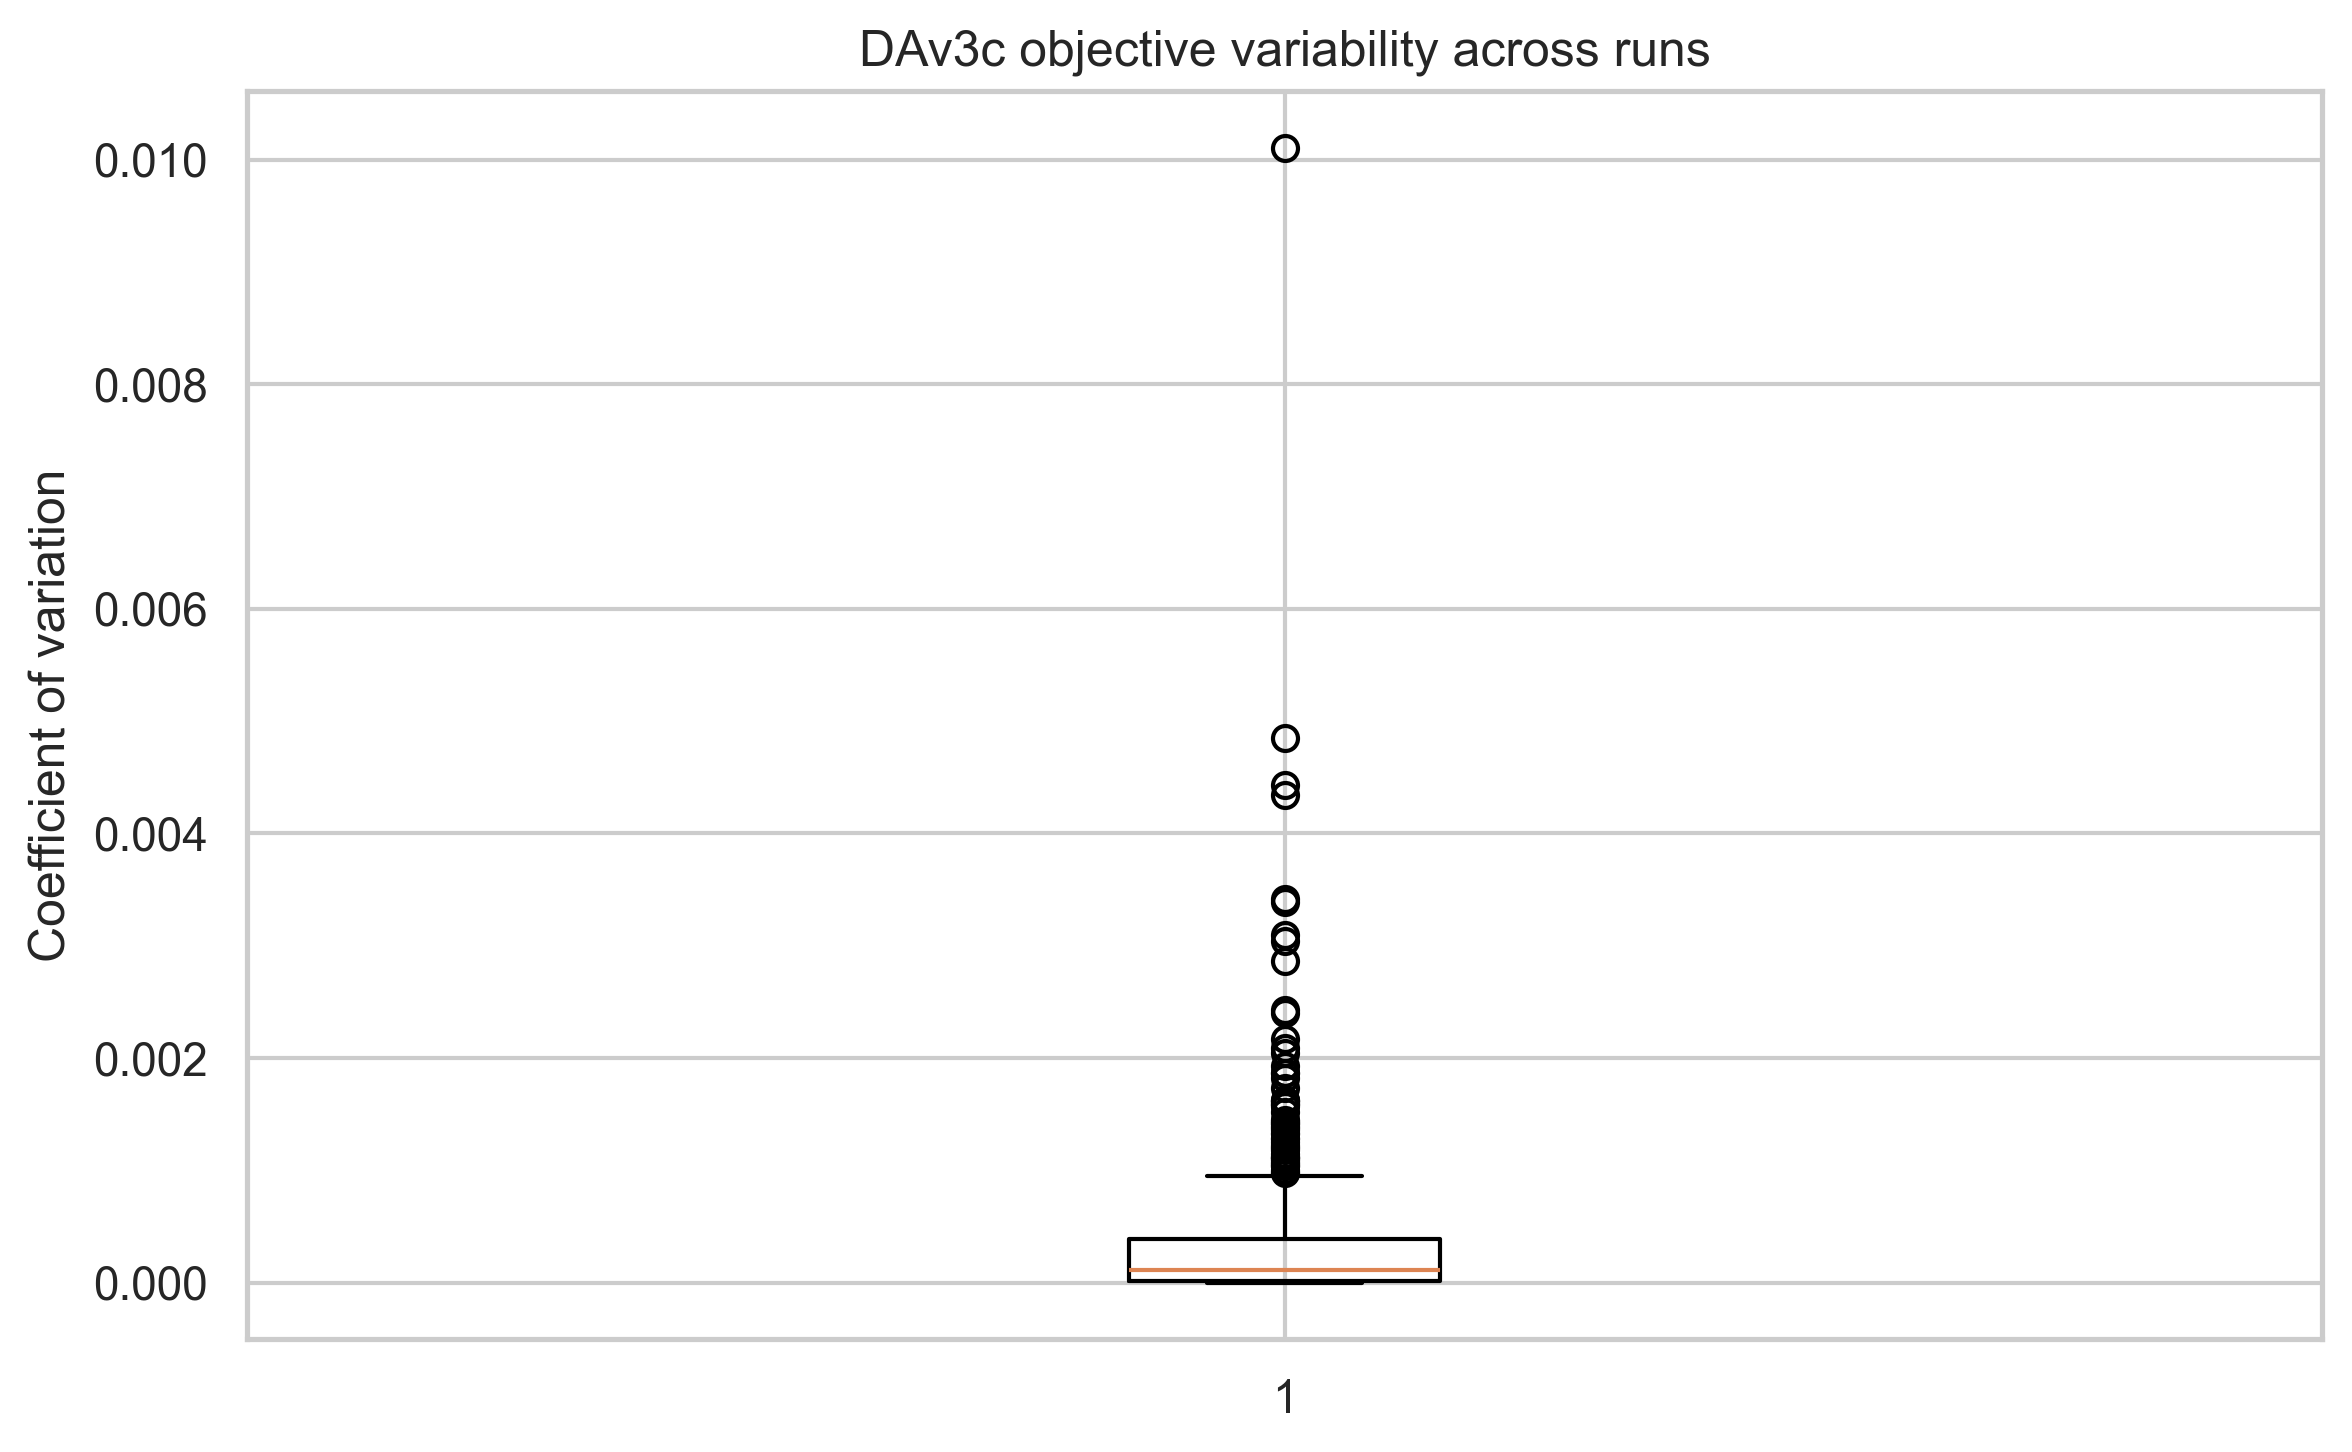

In [10]:
# Exclude perfectly stable instances (CV = 0)
# to better visualize variability across runs.
nonzero_cv = dav3c_stats.loc[
    dav3c_stats["cv"] > 0,
    "cv"
]

fig, ax = plot_boxplot(
    values=nonzero_cv,
    ylabel="Coefficient of variation",
    title="DAv3c objective variability across runs",
    save_name="dav3c_cv_nonzero_distribution.pdf"
)

In [16]:
baseline_enriched = pd.read_csv(PATH_BASELINE_ENRICHED)
baseline_enriched.head()

,name,nodes,edges,density,limit,has_leafs,int_only,size_cat,density_cat,heuristics_name,DAv2,DAv2_runtime,DAv3,DAv3_runtime,DAv3c,DAv3c_runtime,heuristic,heuristic_runtime
0,G55,4969,12498,0.001013,13.945,True,True,large,sparse,BURER2002,10294.0,13.773063,10296.0,16.403668,10200.0,13.121273,10249.0,13.960023
1,G56,4969,12498,0.001013,13.922,True,True,large,sparse,BURER2002,4008.0,13.813462,4015.0,12.644328,3955.0,13.119173,3982.0,13.931711
2,G57,5000,10000,0.000800,11.299,False,True,large,sparse,BURER2002,3468.0,11.263977,3484.0,13.233151,3452.0,11.140920,3424.0,11.312191
3,G58,5000,29570,0.002366,11.876,False,True,large,sparse,BURER2002,19258.0,11.820511,19269.0,12.885950,19178.0,11.147025,19092.0,11.924794
4,G59,5000,29570,0.002366,15.875,False,True,large,sparse,BURER2002,6062.0,15.794570,6077.0,16.119326,5981.0,15.144516,5915.0,15.877029


In [18]:
len(baseline_enriched)

3400

In [19]:
len(baseline_enriched[baseline_enriched['limit'] < 1])

1865

In [20]:
len(baseline_enriched[baseline_enriched['limit'] <= 0.25])

1275

In [21]:
len(baseline_enriched[baseline_enriched['limit'] > 0.25])

2125

In [22]:
baseline_enriched = baseline_enriched[baseline_enriched['limit'] > 0.25]

In [23]:
len(baseline_enriched[baseline_enriched['limit'] > 3600])

3

In [24]:
df_runtime = baseline_enriched [
    (baseline_enriched['limit'] > 0.25) & 
    (baseline_enriched['limit'] < 1)
].copy()

In [25]:
df_runtime['size_cat'].value_counts()

size_cat
xsmall    571
small      19
Name: count, dtype: int64

In [27]:
print(len(df_runtime))
print(df_runtime[['DAv2_runtime','DAv3_runtime','DAv3c_runtime','heuristic_runtime']].describe())

590
       DAv2_runtime  DAv3_runtime  DAv3c_runtime  heuristic_runtime
count    590.000000    590.000000     590.000000         590.000000
mean       0.504057      2.387619       1.020483           0.504950
std        0.199476      0.046130       0.002733           0.200741
min        0.257048      2.281732       1.014380           0.253717
25%        0.331128      2.359786       1.018732           0.332427
50%        0.475387      2.386814       1.020352           0.473884
75%        0.626090      2.416465       1.021898           0.627551
max        1.001040      2.585113       1.054180           1.001455


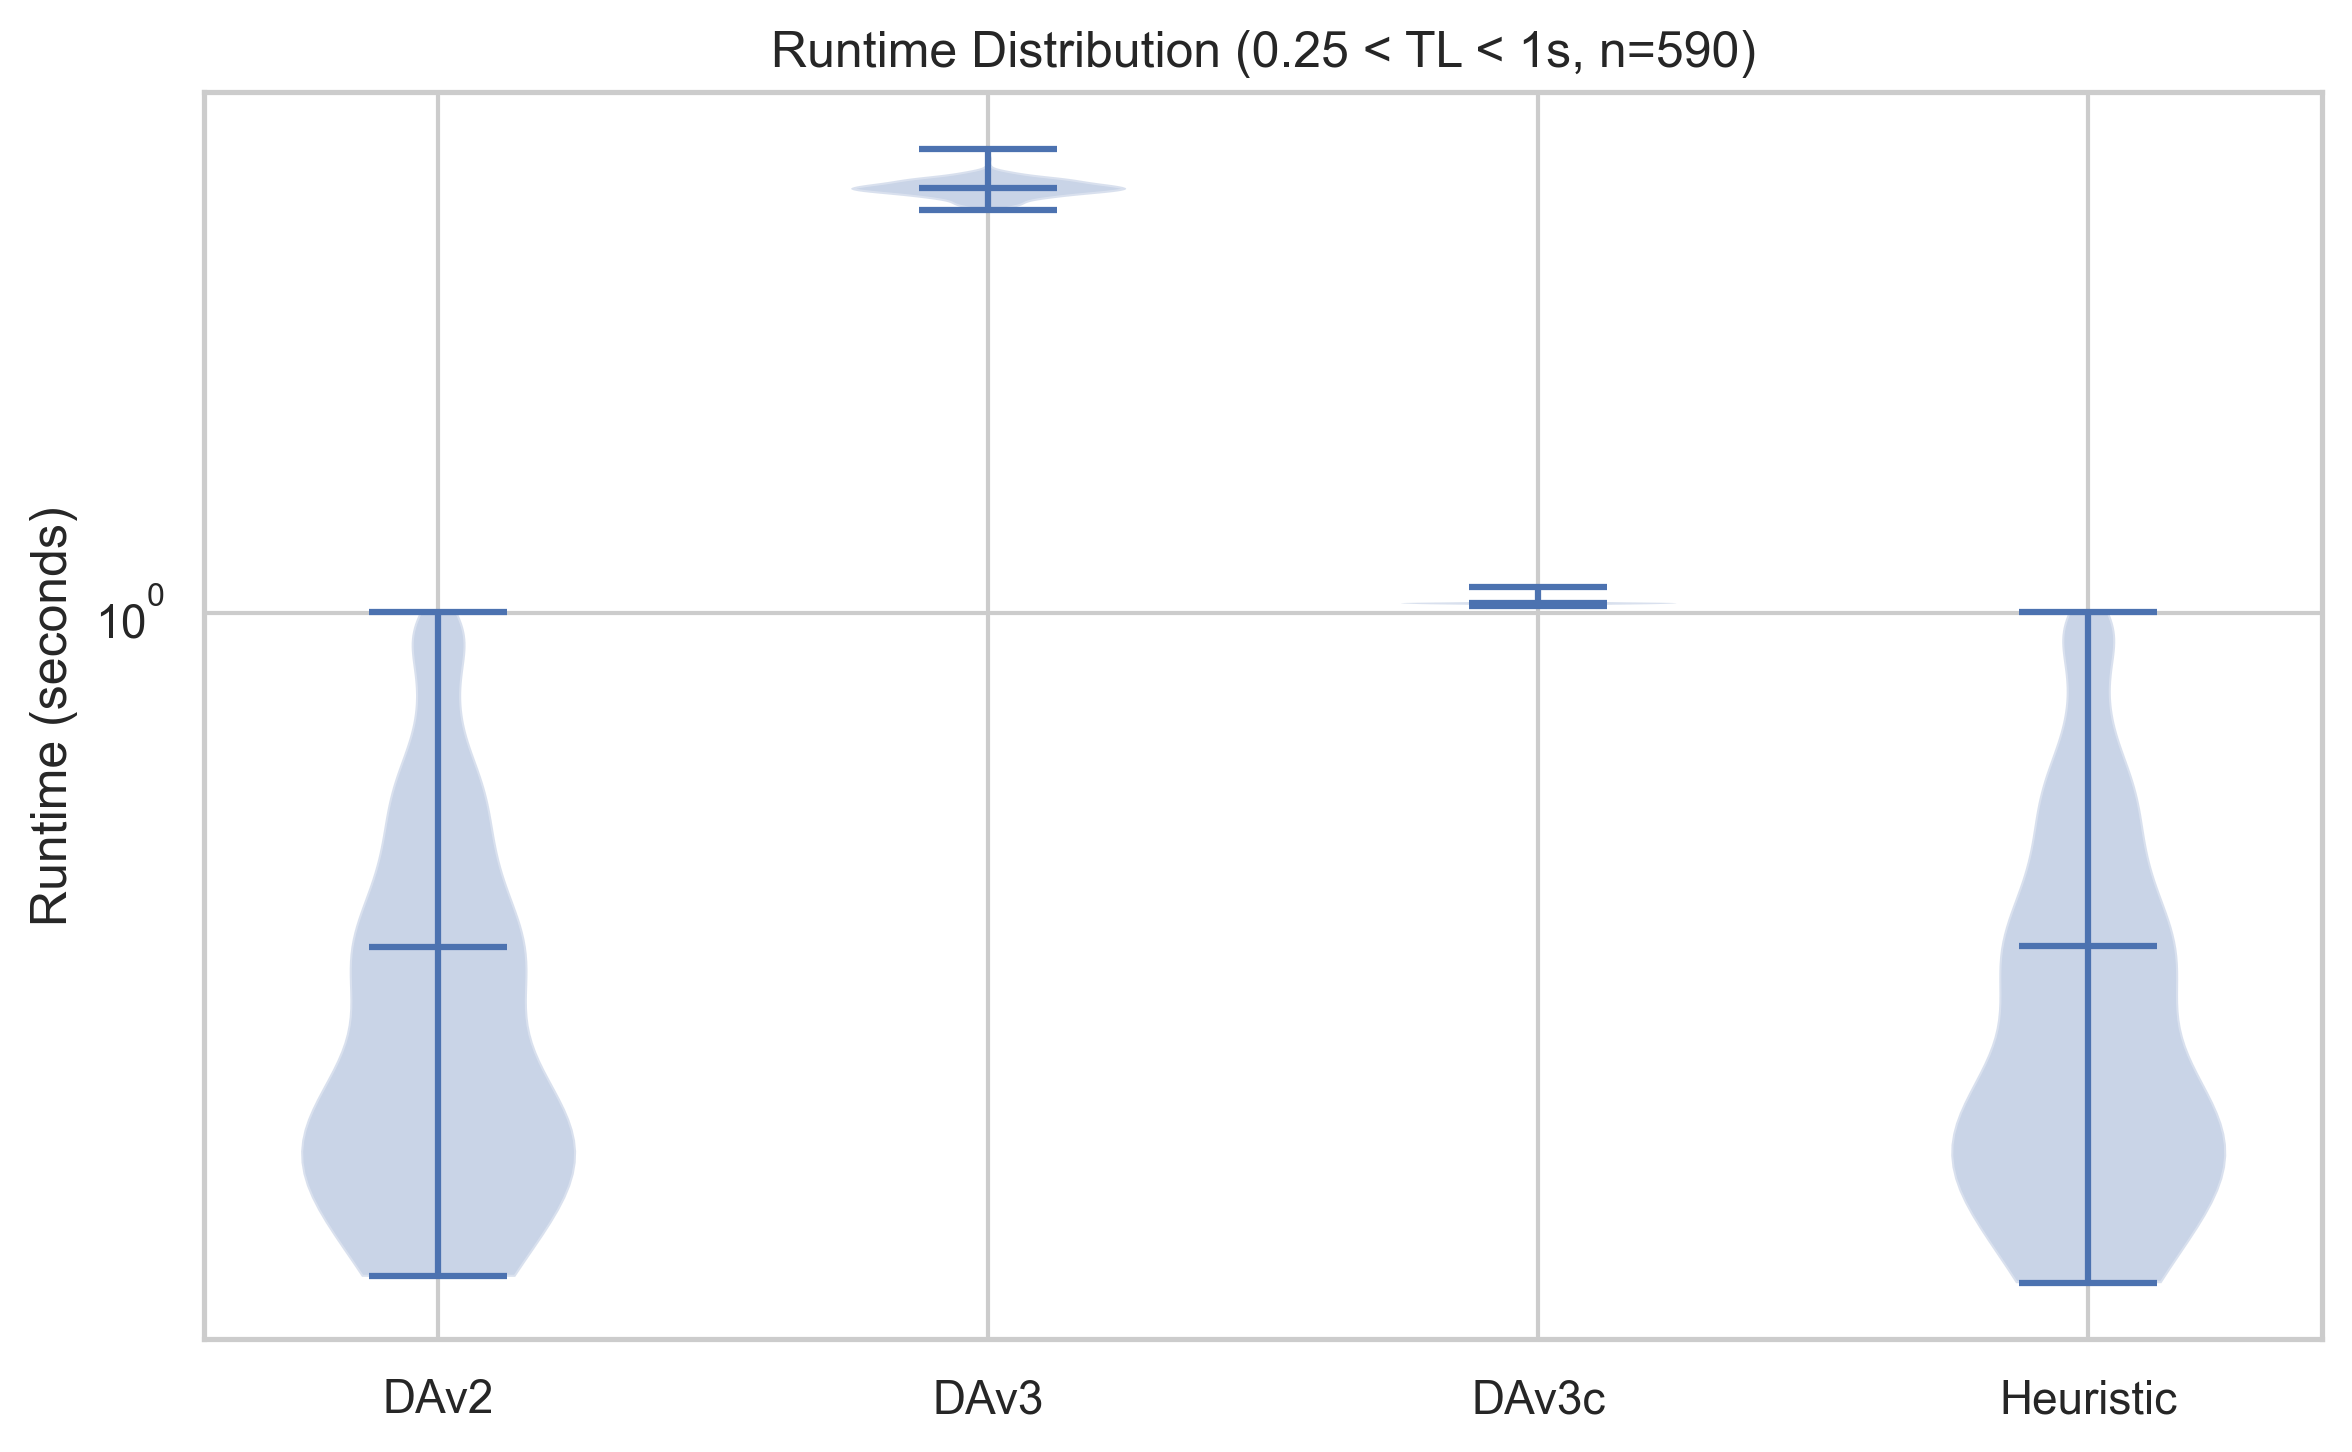

In [30]:
data = [
    df_runtime['DAv2_runtime'].dropna(),
    df_runtime['DAv3_runtime'].dropna(),
    df_runtime['DAv3c_runtime'].dropna(),
    df_runtime['heuristic_runtime'].dropna()
]

labels = ['DAv2', 'DAv3', 'DAv3c', 'Heuristic']

n = len(df_runtime)

fig, ax = plot_violin(
    data=data,
    labels=labels,
    ylabel="Runtime (seconds)",
    title=f"Runtime Distribution (0.25 < TL < 1s, n={n})",
    log_scale=True,
    save_name="runtime_distribution.pdf"
)

In [31]:
df_long = baseline_enriched[baseline_enriched['limit'] > 3600].copy()
print(df_long[['name', 'nodes', 'edges', 'density', 'limit']])

         name  nodes    edges   density     limit
2734  g002750  53130   637560  0.000452  4161.378
2832  g002853  37820  3239100  0.004529  3609.756
3123  g003153  52360  2968064  0.002165  4055.146


In [37]:
print(
    f"""
Instances with time limit > 3600 seconds
{'-' * 50}

Density Categories:
{sorted(df_long['density_cat'].dropna().unique())}

Size Categories:
{sorted(df_long['size_cat'].dropna().unique())}
"""
)


Instances with time limit > 3600 seconds
--------------------------------------------------

Density Categories:
['sparse']

Size Categories:
['xlarge']



In [33]:
cols = [
    'name', 'limit',
    'DAv2_runtime', 'DAv3_runtime', 
    'DAv3c_runtime', 'heuristic_runtime'
]

print(df_long[cols])

         name     limit  DAv2_runtime  DAv3_runtime  DAv3c_runtime  \
2734  g002750  4161.378           NaN   4256.651077    3614.424039   
2832  g002853  3609.756           NaN   3655.930518    3608.336461   
3123  g003153  4055.146           NaN   4080.431155    3613.924020   

      heuristic_runtime  
2734        4161.490277  
2832        3616.672596  
3123        4055.146768  


In [39]:
df_long['DAv3c_vs_DAv3'] = df_long.apply(
    lambda x: utils.compare_scores(x['DAv3c'], x['DAv3']), axis=1
)

df_long['DAv3c_vs_Heuristic'] = df_long.apply(
    lambda x: utils.compare_scores(x['DAv3c'], x['heuristic']), axis=1
)

cols = [
    'name', 'limit',
    'DAv3c', 'DAv3', 'heuristic',
    'DAv3c_vs_DAv3', 'DAv3c_vs_Heuristic'
]

print(df_long[cols].to_string(index=False))

   name    limit        DAv3c         DAv3    heuristic DAv3c_vs_DAv3 DAv3c_vs_Heuristic
g002750 4161.378 2.581903e+06 2.581798e+06 2.589100e+06           win               loss
g002853 3609.756 9.441553e+06 9.440583e+06 9.397778e+06           win                win
g003153 4055.146 1.235248e+06 1.234793e+06 1.234544e+06           win                win
